# Bước 08: Giải Thích Mô Hình Chi Tiết Với SHAP (Explainable AI - XAI)
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers
Nguồn tham chiếu: `srcs/05_machine_learning/Forcasting_v3/12_explainable_ai.py`

**MỤC TIÊU BƯỚC ĐÁNH GIÁ VÀ GIẢI THÍCH MÔ HÌNH (XAI):**
- Sử dụng **SHAP (SHapley Additive exPlanations)** để giải thích độ đóng góp của từng đặc trưng (Feature Importance).
- Phân tích mối quan hệ phi tuyến giữa các biến thời tiết (bức xạ ghi, poa, dhi, nhiệt độ) và sản lượng phát điện.
- Hỗ trợ **cả 2 phương án đặc trưng (`full` có lag_1 vs `no_lag1` không lag_1)** để so sánh sự thay đổi tầm quan trọng của các nhóm tính năng.

## Bước 2. Import thư viện SHAP và khai báo tham số (FEATURE_SET_NAME)

In [2]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import gc
import json
import os
import pickle
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pyarrow.parquet as pq
import seaborn as sns
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Tham số cấu hình ──
VERSION = 'v4'
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

SELECTED_DIR = '../../data/model/v4/05_selected'
TRAIN_BASE_DIR = '../../data/model/v4/06_train'
TEST_FINAL_DIR = '../../data/model/v4/07_final_test'
OUTPUT_DIR = '../../data/model/v4/08_explain'

# Doc model chien thang tu notebook 07; khong hardcode Huber.
best_json = f'{TEST_FINAL_DIR}/best_loss.json'
if not os.path.exists(best_json):
    raise FileNotFoundError(f'Khong tim thay file chon model: {best_json}')
with open(best_json, 'r', encoding='utf-8') as f:
    best_h1 = json.load(f).get('h1', {})

LOSS_NAME = str(best_h1.get('folder_name') or best_h1.get('winning_loss') or '').strip().lower()
FEATURE_SET_NAME = str(best_h1.get('feature_set_name') or '').strip()
if not LOSS_NAME:
    raise ValueError(f'best_loss.json khong co model h1 hop le: {best_h1}')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Đã import thư viện SHAP và khai báo tham số.")
print(f"- Loss name        : {LOSS_NAME}")
print(f"- Feature set name : '{FEATURE_SET_NAME}'")
print(f"- Best-loss file   : {os.path.abspath(best_json)}")
print(f"- Output directory : {os.path.abspath(OUTPUT_DIR)}")


Đã import thư viện SHAP và khai báo tham số.
- Loss name        : mae
- Feature set name : ''
- Best-loss file   : /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v4/07_final_test/best_loss.json
- Output directory : /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v4/08_explain


## Bước 3. Nạp mô hình huấn luyện và dữ liệu tập Test

In [3]:
folder_name = f"{LOSS_NAME}_{FEATURE_SET_NAME}" if FEATURE_SET_NAME else LOSS_NAME
model_path = f'{TRAIN_BASE_DIR}/{folder_name}/h1/model.pkl'

if not os.path.exists(model_path):
    model_path = f'{TRAIN_BASE_DIR}/{folder_name}/model.pkl'

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f'Model duoc chon khong ton tai: {model_path}. '
        f'Kiem tra {best_json} va thu muc {TRAIN_BASE_DIR}.'
    )

print(f"Loss duoc chon: {LOSS_NAME}")
print(f"Đang nạp mô hình từ: {os.path.abspath(model_path)}")
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# Đọc danh sách đặc trưng đã dùng
config_path = model_path.replace('model.pkl', 'model_config.json')
with open(config_path, 'r', encoding='utf-8') as f:
    m_config = json.load(f)

features = m_config['features']
feature_medians = pd.Series(m_config['feature_medians'], dtype=float)

# Nạp tập Test.
# Notebook 06_1 xuat san ma tran test kem dac trung moi (goc mat troi, buc xa downscale,
# quy mo tram). Neu co file do thi dung, vi 05_selected khong chua cac cot nay.
# Ma tran test do NOTEBOOK 07 ghi ra, khong phai notebook 06.
# Tap test chi duoc mo DUY NHAT 1 lan o notebook 07 (sau khi mo hinh vo dich da chon
# xong bang so lieu validation). Notebook nay dung lai snapshot do - khong tu mo test.
# Truoc day dong nay tro vao 06_train/<loss>/h1/X_test_h1.parquet, nhung tu khi khoa
# tap test thi notebook 06 khong con ghi file do -> se doc phai file cu.
x_test_path = f'{TEST_FINAL_DIR}/h1/X_test_h1.parquet'

if os.path.exists(x_test_path):
    print(f"Dùng ma trận test có sẵn từ notebook 06: {x_test_path}")
    test_df = pd.read_parquet(x_test_path)
else:
    test_path = f'{SELECTED_DIR}/{VERSION}_test_selected.parquet'
    print(f"Không thấy ma trận có sẵn, đọc từ: {test_path}")
    test_df = pd.read_parquet(test_path)
    if 'exclude_from_training' in test_df.columns:
        test_df = test_df[test_df['exclude_from_training'] == False]
    if 'has_complete_history_features' in test_df.columns:
        test_df = test_df[test_df['has_complete_history_features'] == True]

test_df = test_df.reset_index(drop=True)
feat_cols = [c for c in features if c in test_df.columns]
num_cols = [c for c in feat_cols if pd.api.types.is_numeric_dtype(test_df[c])]
feat_cols = num_cols

_thieu = [c for c in features if c not in feat_cols]
if _thieu:
    print(f"[CANH BAO] Thieu {len(_thieu)} dac trung trong tap test: {_thieu[:8]}")

X_test_full = test_df[feat_cols].fillna(feature_medians).astype(float)
print(f"Đã nạp tập Test gồm {len(X_test_full):,} dòng và {len(feat_cols)} đặc trưng.")


Loss duoc chon: mae
Đang nạp mô hình từ: /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v4/06_train/mae/h1/model.pkl
Dùng ma trận test có sẵn từ notebook 06: ../../data/model/v4/07_final_test/h1/X_test_h1.parquet
Đã nạp tập Test gồm 475,599 dòng và 53 đặc trưng.


## Bước 4. Tính toán giá trị SHAP (TreeExplainer)

In [4]:
# ── SHAP tren TOAN BO ma tran test, khong lay mau ──
# Truoc day cell nay lay ngau nhien 2.000 dong cho nhanh, nen bang xep hang tam quan
# trong chi la uoc luong tren mau. Nay tinh cho tat ca cac dong.
#
# Dung `booster_.predict(pred_contrib=True)` thay vi `shap.TreeExplainer`: LightGBM cai
# dat san chinh thuat toan TreeSHAP cua Lundberg trong loi C++, cho ra CUNG bo gia tri
# nhung nhanh hon nhieu bac. Cot cuoi cung pred_contrib tra ve la gia tri co so.
import time

N = len(X_test_full)
LO = 100_000
n_lo = (N + LO - 1) // LO
print(f"Tinh SHAP tren TOAN BO {N:,} dong x {len(feat_cols)} dac trung "
      f"({n_lo} lo, moi lo {LO:,} dong)...")

_booster = model.booster_ if hasattr(model, 'booster_') else model
_t0 = time.time()
_phan = []
_co_so = None
for i in range(n_lo):
    a, b = i * LO, min((i + 1) * LO, N)
    _ct = np.asarray(_booster.predict(X_test_full.iloc[a:b], pred_contrib=True),
                     dtype=np.float32)
    if _co_so is None:
        _co_so = float(_ct[0, -1])
    _phan.append(_ct[:, :-1])
    print(f"   lo {i + 1}/{n_lo}: dong {a:,}-{b:,} | {time.time() - _t0:,.0f}s")

shap_values = np.concatenate(_phan, axis=0)
del _phan
gc.collect()
print(f"Xong trong {time.time() - _t0:,.0f}s. Ma tran SHAP: {shap_values.shape} "
      f"| gia tri co so {_co_so:.6f}")

# Kiem tinh cong: tong dong gop + gia tri co so phai bang du bao cua mo hinh.
_thu = model.predict(X_test_full.iloc[:2000])
_sai_so = float(np.abs(shap_values[:2000].sum(axis=1) + _co_so - _thu).max())
print(f"Kiem tinh cong (2.000 dong dau): sai lech lon nhat {_sai_so:.3e}")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_importance = pd.DataFrame({
    'feature': feat_cols,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)
df_importance['so_dong_tinh'] = N

print(f"\nTOP 10 DAC TRUNG QUAN TRONG NHAT (SHAP, tinh tren ca {N:,} dong):")
display(df_importance.head(10))

suffix = f"_{FEATURE_SET_NAME}" if FEATURE_SET_NAME else ""
df_importance.to_csv(f'{OUTPUT_DIR}/shap_importance{suffix}.csv', index=False)
df_importance.to_csv(f'{OUTPUT_DIR}/shap_importance.csv', index=False)

df_shap = pd.DataFrame(shap_values, columns=feat_cols, index=X_test_full.index)
df_shap_full = pd.concat([test_df[[SITE_COL, TIMESTAMP_COL]].copy(), df_shap], axis=1)
df_shap_full.to_parquet(f'{OUTPUT_DIR}/shap_values{suffix}.parquet', index=False)
df_shap_full.to_parquet(f'{OUTPUT_DIR}/shap_values.parquet', index=False)
del df_shap, df_shap_full
gc.collect()

# Beeswarm ve 475k dong se treo trinh ve, nen rieng phan HINH dung mau ngau nhien co
# dinh. Bang xep hang o tren van la so tren toan bo du lieu.
np.random.seed(42)
N_VE = min(20_000, N)
idx_ve = np.sort(np.random.choice(N, size=N_VE, replace=False))
X_sample = X_test_full.iloc[idx_ve].copy()
shap_sample = shap_values[idx_ve]
print(f"\nMau danh RIENG cho hinh beeswarm: {N_VE:,} dong (bang xep hang van la {N:,}).")


class _CoSo:
    """Giu gia tri co so cho bieu do waterfall, thay cho explainer cua thu vien shap."""
    expected_value = _co_so


explainer = _CoSo()
print(f"Da luu ket qua SHAP ({FEATURE_SET_NAME}) vao thu muc: {OUTPUT_DIR}")

Tinh SHAP tren TOAN BO 475,599 dong x 53 dac trung (5 lo, moi lo 100,000 dong)...
   lo 1/5: dong 0-100,000 | 377s
   lo 2/5: dong 100,000-200,000 | 775s
   lo 3/5: dong 200,000-300,000 | 1,196s
   lo 4/5: dong 300,000-400,000 | 1,608s
   lo 5/5: dong 400,000-475,599 | 1,915s
Xong trong 1,915s. Ma tran SHAP: (475599, 53) | gia tri co so 0.687160
Kiem tinh cong (2.000 dong dau): sai lech lon nhat 1.399e-07

TOP 10 DAC TRUNG QUAN TRONG NHAT (SHAP, tinh tren ca 475,599 dong):


,feature,mean_abs_shap,so_dong_tinh
18,direct_normal_irradiance,0.086925,475599
2,ky_vong,0.085992,475599
3,rolling_min_4,0.080486,475599
44,ghi_cs_mt,0.075536,475599
0,rolling_max_4,0.067814,475599
1,rolling_mean_4,0.056607,475599
15,minute_of_day,0.047543,475599
31,tran_cong_suat,0.038245,475599
11,rolling_std_4,0.033819,475599
22,weather_condition_enc,0.021752,475599



Mau danh RIENG cho hinh beeswarm: 20,000 dong (bang xep hang van la 475,599).
Da luu ket qua SHAP () vao thu muc: ../../data/model/v4/08_explain


## Bước 5. Trực quan hóa Global SHAP Summary / Beeswarm Plot

--- BIEU DO GLOBAL SHAP BEESWARM PLOT ---
Thu tu dac trung lay tu bang xep hang tren TOAN BO 475,599 dong; cham ve tren mau 20,000 dong cho hinh doc duoc.


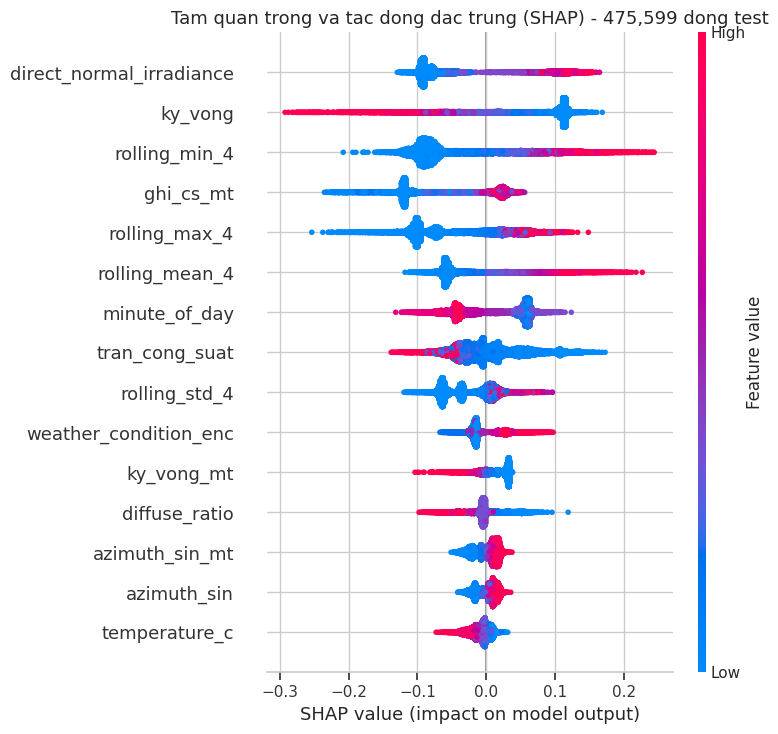

Da ghi: ../../data/model/v4/08_explain/notebook_shap_beeswarm.png


In [5]:
print("--- BIEU DO GLOBAL SHAP BEESWARM PLOT ---")
print(f"Thu tu dac trung lay tu bang xep hang tren TOAN BO {N:,} dong; "
      f"cham ve tren mau {N_VE:,} dong cho hinh doc duoc.")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_sample, X_sample, max_display=15, show=False)
plt.title(f"Tam quan trong va tac dong dac trung (SHAP) - {N:,} dong test", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/notebook_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Da ghi: {OUTPUT_DIR}/notebook_shap_beeswarm.png")

## Bước 6. Phân tích mối quan hệ phụ thuộc (SHAP Dependence Plots)

--- BIỂU ĐỒ SHAP DEPENDENCE PLOTS CHO 4 ĐẶC TRƯNG HÀNG ĐẦU ---


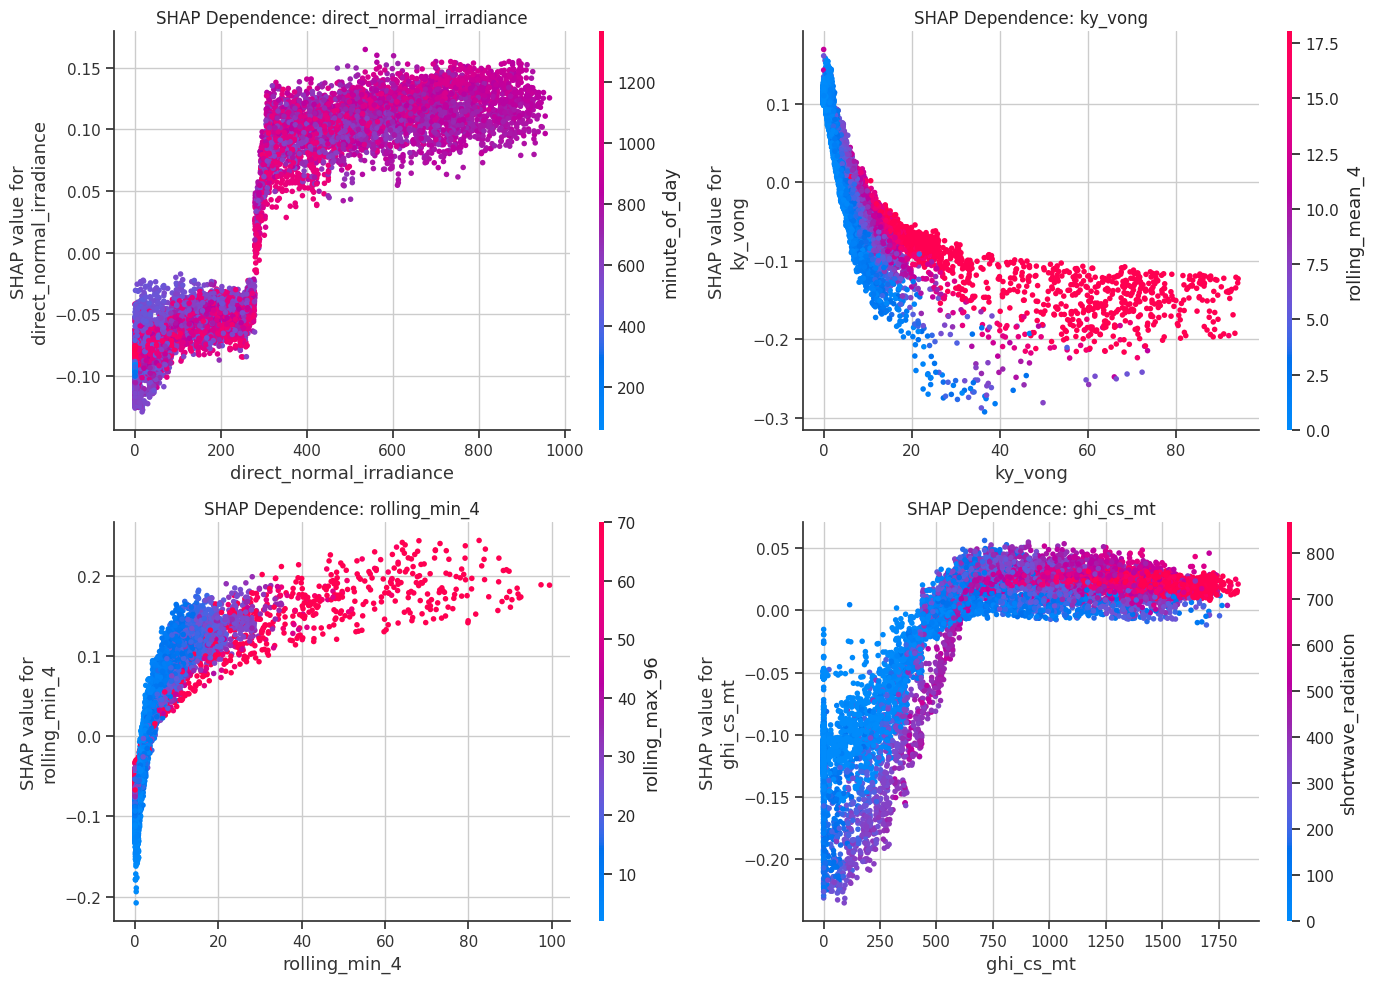

In [6]:
top_features = df_importance['feature'].head(4).tolist()
print("--- BIỂU ĐỒ SHAP DEPENDENCE PLOTS CHO 4 ĐẶC TRƯNG HÀNG ĐẦU ---")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_sample, X_sample, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP Dependence: {feat}")

plt.tight_layout()
plt.show()

## Bước 7. Giải thích mô hình cục bộ (Local Waterfall Plot)

--- BIEU DO SHAP WATERFALL PLOT CHO CAC MAU LOCAL ---


,site_id,timestamp,case_label,actual_kwh,prediction_normalized,shap_total_normalized
0,10,2022-03-09 10:15:00,upward_contribution,5.531250,1.355595,6.684346e-01
1,27,2022-01-28 17:15:00,downward_contribution,2.875000,-0.123862,-8.110223e-01
2,36,2022-03-31 17:15:00,near_baseline,2.890625,0.687160,-1.424924e-07


Da luu 3 mau local SHAP vao: /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v4/08_explain


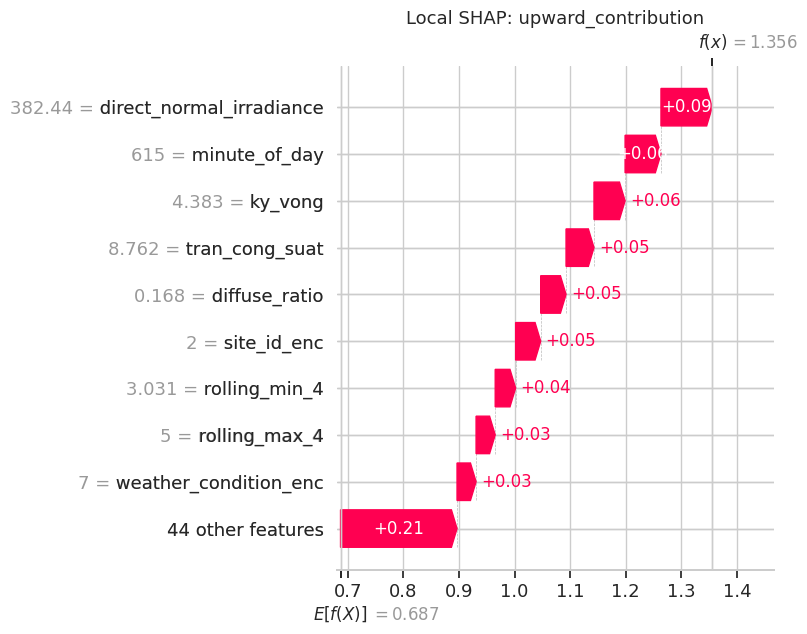

Da ghi: ../../data/model/v4/08_explain/local_shap_mae_h1_upward.png


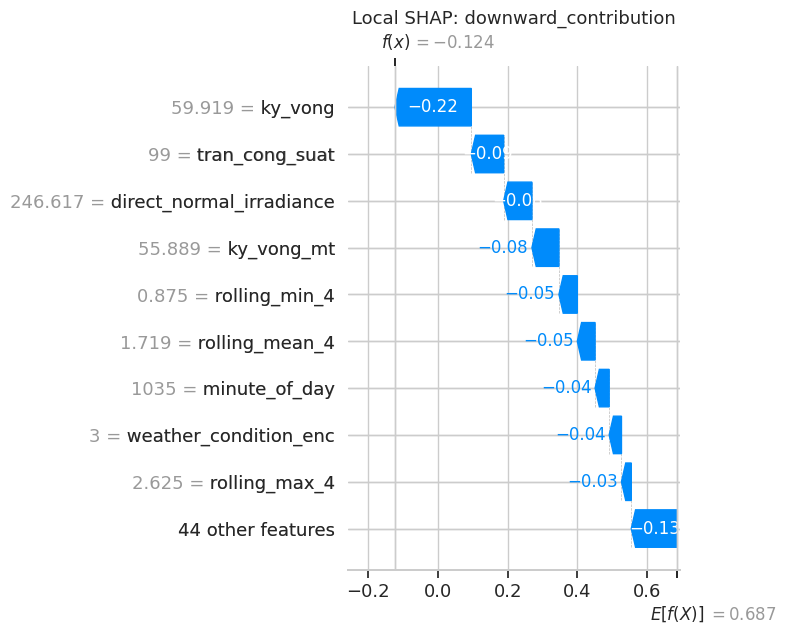

Da ghi: ../../data/model/v4/08_explain/local_shap_mae_h1_downward.png


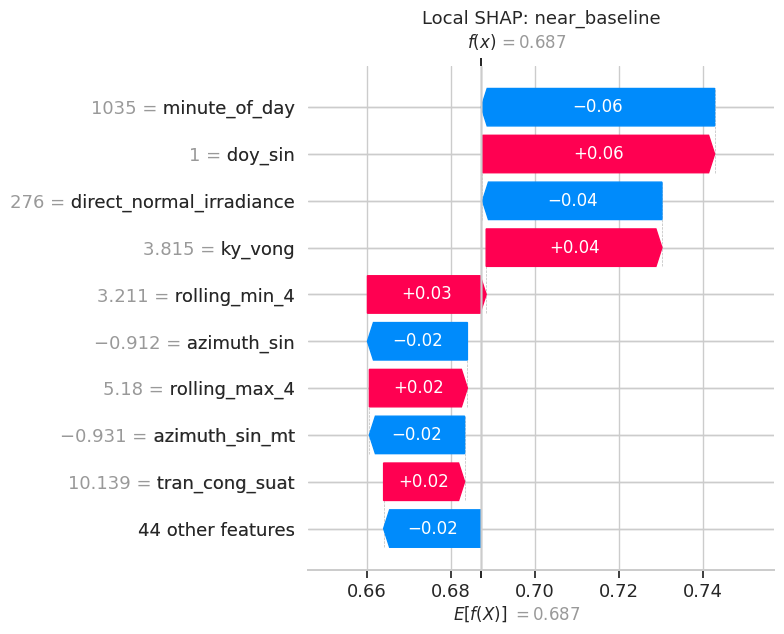

Da ghi: ../../data/model/v4/08_explain/local_shap_mae_h1_baseline.png


In [7]:
print("--- BIEU DO SHAP WATERFALL PLOT CHO CAC MAU LOCAL ---")
# Ba ca duoc chon tren TOAN BO ma tran test, nen day la cuc tri that su cua tap test
# chu khong phai cuc tri cua mot mau ngau nhien.
shap_total = np.asarray(shap_values).sum(axis=1)
local_positions = {
    'upward_contribution': int(np.argmax(shap_total)),
    'downward_contribution': int(np.argmin(shap_total)),
    'near_baseline': int(np.argmin(np.abs(shap_total))),
}
_ten_file = {
    'upward_contribution': 'local_shap_mae_h1_upward.png',
    'downward_contribution': 'local_shap_mae_h1_downward.png',
    'near_baseline': 'local_shap_mae_h1_baseline.png',
}

local_records = []
for case_label, pos in local_positions.items():
    source_row = test_df.iloc[pos]
    record = {
        SITE_COL: source_row[SITE_COL],
        TIMESTAMP_COL: source_row[TIMESTAMP_COL],
        'case_label': case_label,
        'actual_kwh': source_row[TARGET_COL] if TARGET_COL in source_row else np.nan,
        'prediction_normalized': float(np.asarray(
            model.predict(X_test_full.iloc[[pos]])).reshape(-1)[0]),
        'shap_total_normalized': float(shap_total[pos]),
        'so_dong_quet': N,
    }
    record.update({f'shap_{feature}': float(value)
                   for feature, value in zip(feat_cols, shap_values[pos])})
    local_records.append(record)

local_cases = pd.DataFrame(local_records)
local_cases.to_parquet(f'{OUTPUT_DIR}/local_shap_cases.parquet', index=False)
local_cases.to_csv(f'{OUTPUT_DIR}/local_shap_cases.csv', index=False)
display(local_cases[[SITE_COL, TIMESTAMP_COL, 'case_label', 'actual_kwh',
                     'prediction_normalized', 'shap_total_normalized']])
print(f"Da luu 3 mau local SHAP vao: {os.path.abspath(OUTPUT_DIR)}")

for case_label, pos in local_positions.items():
    ex = shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X_test_full.iloc[pos].values,
        feature_names=feat_cols,
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(ex, max_display=10, show=False)
    plt.title(f"Local SHAP: {case_label}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{_ten_file[case_label]}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Da ghi: {OUTPUT_DIR}/{_ten_file[case_label]}")

## Bước 8. Biểu đồ Plotly Tương tác Dropdown cho 42 Trạm

In [8]:
print("Đang chuẩn bị biểu đồ Plotly tương tác cho 42 trạm quang điện...")

audit_path = f'{TEST_FINAL_DIR}/prediction_audit.parquet'
if os.path.exists(audit_path):
    audit_df = pd.read_parquet(audit_path)
else:
    audit_df = test_df[[SITE_COL, TIMESTAMP_COL, TARGET_COL]].copy()
    audit_df = audit_df.rename(columns={TARGET_COL: 'y_true'})
    audit_df['y_pred'] = model.predict(X_test_full)

y_true_col = 'y_true_h1' if 'y_true_h1' in audit_df.columns else ('y_true' if 'y_true' in audit_df.columns else TARGET_COL)
y_pred_col = 'y_pred_h1' if 'y_pred_h1' in audit_df.columns else 'y_pred'

sites = sorted(audit_df[SITE_COL].unique())

fig = go.Figure()

for i, s_id in enumerate(sites):
    site_data = audit_df[audit_df[SITE_COL] == s_id].sort_values(TIMESTAMP_COL).head(300)
    visible = (i == 0)

    fig.add_trace(go.Scatter(
        x=site_data[TIMESTAMP_COL], y=site_data[y_true_col],
        mode='lines', name='Thực tế (' + str(s_id) + ')',
        visible=visible, line=dict(color='blue')
    ))
    fig.add_trace(go.Scatter(
        x=site_data[TIMESTAMP_COL], y=site_data[y_pred_col],
        mode='lines', name='Dự báo (' + str(s_id) + ')',
        visible=visible, line=dict(color='orange', dash='dash')
    ))

buttons = []
for i, s_id in enumerate(sites):
    visible_list = [False] * (len(sites) * 2)
    visible_list[i * 2] = True
    visible_list[i * 2 + 1] = True

    buttons.append(dict(
        label=str(s_id),
        method='update',
        args=[{'visible': visible_list}, {'title': 'Dự Báo vs Thực Tế tại Trạm: ' + str(s_id)}]
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0.15, y=1.15, xanchor='left', yanchor='top')],
    title='Dự Báo vs Thực Tế tại Trạm: ' + str(sites[0]),
    xaxis_title='Thời gian',
    yaxis_title='Sản lượng (kWh)',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

Đang chuẩn bị biểu đồ Plotly tương tác cho 42 trạm quang điện...
